In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import numpy as np

manualSeed = 999
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True)

# Data

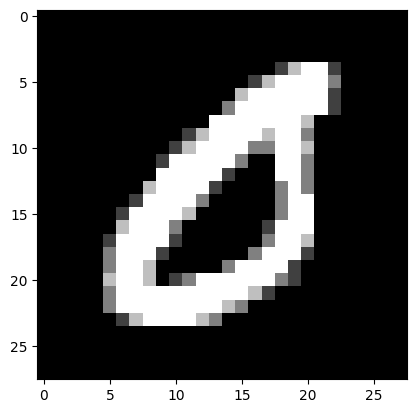

Labels:     0


In [2]:
from preprocessing.mnist import train_valid_test, display_sample, imshow

batch_size = 1
n_train = 100  # samples per class
n_valid = 400
classes = range(2)

trainloader, validloader, testloader = train_valid_test(classes, batch_size=batch_size, n_train=n_train, n_valid=n_valid)
display_sample(trainloader)

# Model Init

In [3]:
from models.qnet import QCNet
from train.eval import num_params
from train.config import device

arch = QCNet

model = arch(len(classes)).to(device)
print(f"{model.__class__.__name__} has {num_params(model)} parameters")

print("Model QC below:")
model.q1.qc.qc.draw(style="clifford")

QCNet has 44485 parameters
Model QC below:


/Users/petergao/Documents/GitHub/Quantum/Digit-Classifier/qintegration/qutils.py:80: RuntimeWarning: invalid value encountered in divide
  return output / output.sum()


┌───────────────┐ ░ ┌─────────────────┐                »
   q_0: ┤ Rx(inputs[0]) ├─░─┤0                ├─■──────────────»
        ├───────────────┤ ░ │  Rxx(params[0]) │ │ZZ(params[1]) »
   q_1: ┤ Rx(inputs[1]) ├─░─┤1                ├─■──────────────»
        ├───────────────┤ ░ └─────────────────┘                »
   q_2: ┤ Rx(inputs[2]) ├─░────────────────────────────────────»
        └───────────────┘ ░                                    »
   c: 3/═══════════════════════════════════════════════════════»
                                                               »
meas: 3/═══════════════════════════════════════════════════════»
                                                               »
«                                           ┌─────────────────┐                »
«   q_0: ───────────────────────────────────┤1                ├─■──────────────»
«        ┌─────────────────┐                │                 │ │              »
«   q_1: ┤0                ├─■──────────────┤  Rxx(params[4]) ├─┼──────────────»
«        │  Rxx(params[2]) │ │ZZ(params[3]) │                 │ │ZZ(params[5]) »
«   q_2: ┤1                ├─■──────────────┤0                ├─■──────────────»
«        └─────────────────┘                └─────────────────┘                »
«   c: 3/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«meas: 3/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«         ░  ░ ┌─┐      
«   q_0: ─░──░─┤M├──────
«         ░  ░ └╥┘┌─┐   
«   q_1: ─░──░──╫─┤M├───
«         ░  ░  ║ └╥┘┌─┐
«   q_2: ─░──░──╫──╫─┤M├
«         ░  ░  ║  ║ └╥┘
«   c: 3/═══════╬══╬══╬═
«               ║  ║  ║ 
«meas: 3/═══════╩══╩══╩═
«               0  1  2

# Training

In [4]:
from train.train import train, distill
from train.validate import Validate

criterion = nn.CrossEntropyLoss()
def regularization(model: arch):
    return -0.1 * torch.tensor([torch.norm(head.w) for head in model.q1.heads]).mean()

### Distill

[1, 10] loss: 0.682
tensor([-0.0748, -0.4321], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[1, 20] loss: 0.740
tensor([-0.1030, -0.4168], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[1, 30] loss: 0.681
tensor([-0.1128, -0.4089], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[1, 40] loss: 0.721
tensor([-0.1952, -0.3935], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 50] loss: 0.683
tensor([-0.1267, -0.3933], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[1, 60] loss: 0.718
tensor([-0.1885, -0.3779], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 70] loss: 0.696
tensor([-0.2004, -0.3692], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 80] loss: 0.680
tensor([-0.2160, -0.3626], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.500
[1, 90] loss: 0.680
tensor([-0.1641, -0.3573], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.500
[

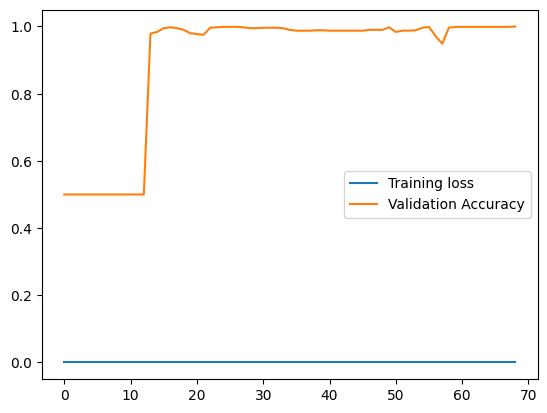

In [5]:
from models.cnet import SNet

TEACHER_PATH = './trained_models/clnet.pth'

teacher_arch = SNet
teacher = teacher_arch(len(classes)).to(device)
teacher.load_state_dict(torch.load(TEACHER_PATH))
teacher = teacher.eval()

distillation_criterion = nn.CrossEntropyLoss()
teacher_process = nn.Softmax(dim=1)

(best_acc, best_model), distill_validate = distill(
    model, trainloader, validloader, criterion, 
    teacher, distillation_criterion, teacher_process=teacher_process, weight=0.5,
    regularization=regularization,
    lr=0.002, epochs=15,
    val_gap=10, verbose=True
)

distill_validate.show_history()

### True Training

[1, 10] loss: 0.124
tensor([ 0.3245, -0.6253], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 1.000
Finished Training


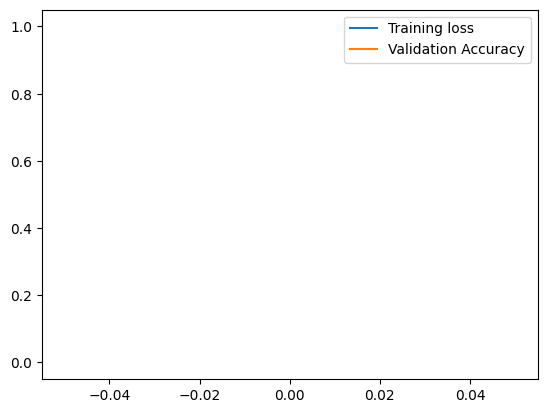

In [6]:
import copy

model = copy.deepcopy(best_model)
(best_acc, best_model), train_validate = train(
    model, trainloader, validloader, criterion, 
    regularization=regularization,
    lr=0.0005, epochs=15,
    val_gap=10, verbose=True,
    best=(best_acc, best_model)
)

train_validate.show_history()

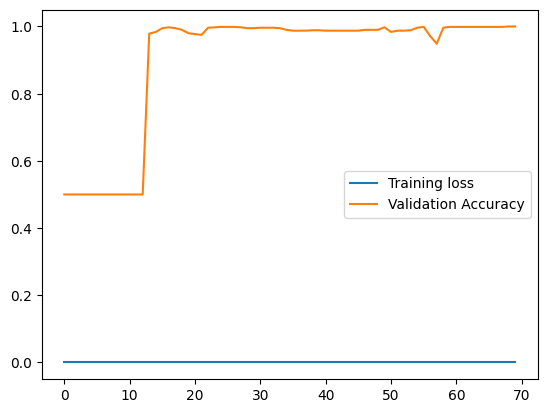

In [10]:
if (type(distill_validate) == type(train_validate)):
    distill_validate.show_history(distill_validate.history + train_validate.history)

In [11]:
PATH = './trained_models/qnet.pth'
torch.save(best_model.state_dict(), PATH)

# Model Evaluation

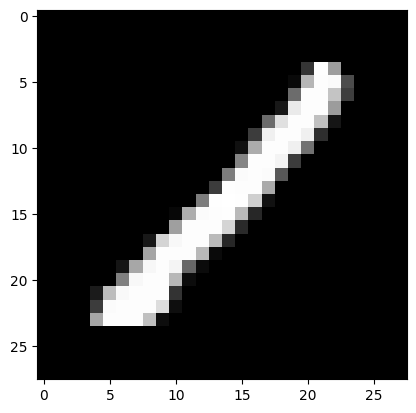

Labels:     1
Predictions:     1


In [12]:
model = arch(len(classes)).to(device)
model.load_state_dict(torch.load(PATH))

display_sample(testloader, model=model)

Accuracy of the model on the test images with quantum layer: 99.82350581628559 %
Incorrectly predicted images


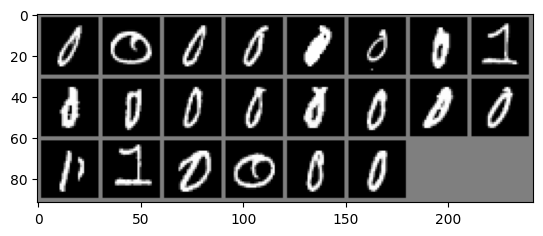

In [13]:
from train.eval import get_acc

acc, errors = get_acc(model, testloader)
print(f'Accuracy of the model on the test images with quantum layer: {100 * acc} %')

print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors))

Recall for class:     0 is 99.7 %
Recall for class:     1 is 100.0 %
Incorrectly predicted images


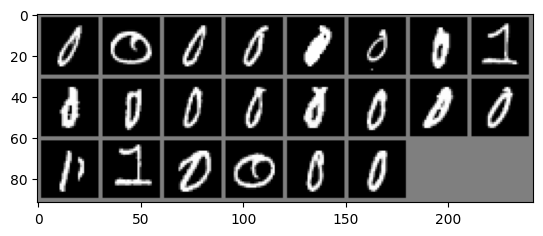

In [14]:
from train.eval import get_class_accs

class_accs = get_class_accs(model, testloader)
for classname in classes:
    print(f'Recall for class: {classname:5d} is {class_accs[classname]*100:.1f} %')

print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors))

In [15]:
for head in model.q1.heads:
    print(head.w)
    head.w = nn.Parameter(torch.zeros(head.w.shape))

acc, errors = get_acc(model, testloader)
print(f'Accuracy of the model on the test images without quantum layer: {100 * acc} %')

Parameter containing:
tensor([ 0.0084, -1.1690,  0.3489,  0.0054, -0.1104,  0.0478],
       requires_grad=True)
Accuracy of the model on the test images without quantum layer: 99.80746089049339 %


# Training an ensemble

In [16]:
# for i in range(5):
#     acc = 0
#     # only allow accuracy models
#     while acc < .9:
#         model, _ = train(arch(), verbose=False)
#         with torch.no_grad():
#             acc = val_acc(model)
#             print(i, acc)

#     PATH = f'./trained_models/qnet{i}.pth'
#     torch.save(model.state_dict(), PATH)
#     print(f"Finished model {i}")